
# 06. Neural Language Models and Training Pipeline

## Models covered
1. Vanilla LSTM
2. Stacked LSTM
3. BiLSTM
4. GRU
5. CNN + LSTM
6. Transformer LM

## Training workflow
- Train/val/test separation
- Early stopping
- Learning-rate scheduling
- Gradient clipping
- Checkpointing
- Cross-entropy and perplexity monitoring


In [1]:

from pathlib import Path
import subprocess
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

leaderboard_path = RESULTS_DIR / "leaderboard_quick_cpu.csv"
if not leaderboard_path.exists():
    cmd = [
        "uv", "run", "python", "scripts/train_and_benchmark.py",
        "--profile", "quick",
        "--include-wikitext",
        "--prefer-gpu",
        "--wikitext-train-tokens", "60000",
        "--wikitext-val-tokens", "10000",
        "--wikitext-test-tokens", "10000",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

leaderboard = pd.read_csv(leaderboard_path)
leaderboard


,model,family,cross_entropy,perplexity,top1_accuracy,top3_accuracy,top5_accuracy,recall_at_3,recall_at_5,mrr,avg_latency_ms,throughput_examples_per_sec,memory_rss_mb_before,memory_rss_mb_after,memory_delta_mb,timed_batches,train_time_sec,rank_score
0,BiLSTM,neural,4.666769,1.063535e+02,0.181039,0.310565,0.384864,0.310565,0.384864,0.279847,1.021022,122303.981454,1842.718750,1842.718750,0.000000,24.0,3.947504,33.168714
1,LSTM,neural,4.681628,1.079457e+02,0.162810,0.300093,0.373741,0.300093,0.373741,0.269392,0.855646,145942.279046,1814.773438,1814.785156,0.011719,24.0,5.620216,31.976807
2,GRU,neural,4.767888,1.176704e+02,0.165334,0.298982,0.369374,0.298982,0.369374,0.265408,1.232944,101281.938067,1843.023438,1843.023438,0.000000,24.0,3.527344,31.053881
3,CNN_LSTM,neural,4.821506,1.241519e+02,0.169295,0.292963,0.358798,0.292963,0.358798,0.264275,1.058595,117962.904625,1961.855469,1961.855469,0.000000,24.0,4.184091,29.672173
4,StackedLSTM,neural,4.818019,1.237197e+02,0.155838,0.291630,0.357274,0.291630,0.357274,0.256875,1.650768,75646.608128,1834.207031,1834.207031,0.000000,24.0,3.216127,29.541463
5,Transformer,neural,4.817051,1.236001e+02,0.137124,0.275114,0.352017,0.275114,0.352017,0.241543,0.977504,127748.892397,2104.714844,2104.714844,0.000000,24.0,5.187598,29.021697
6,Bigram,ngram,6.013678,4.089848e+02,0.187109,0.325000,0.391797,0.325000,0.391797,0.278482,69.667998,1837.285458,1293.949219,1293.957031,0.007812,5.0,NaN,18.730446
7,Unigram,ngram,5.325987,2.056111e+02,0.147266,0.208984,0.279297,0.208984,0.279297,0.217160,805.435083,158.920319,1293.839844,1293.839844,0.000000,5.0,NaN,17.649134
8,Trigram,ngram,6.538057,6.909430e+02,0.160547,0.266016,0.319922,0.266016,0.319922,0.214741,256.693152,498.649842,1298.375000,1298.386719,0.011719,5.0,NaN,6.992188
9,MostFrequent,ngram,23.540335,1.672775e+10,0.148047,0.148047,0.191016,0.148047,0.191016,0.149013,50.189905,2550.313644,1293.722656,1293.722656,0.000000,5.0,NaN,-5.898438


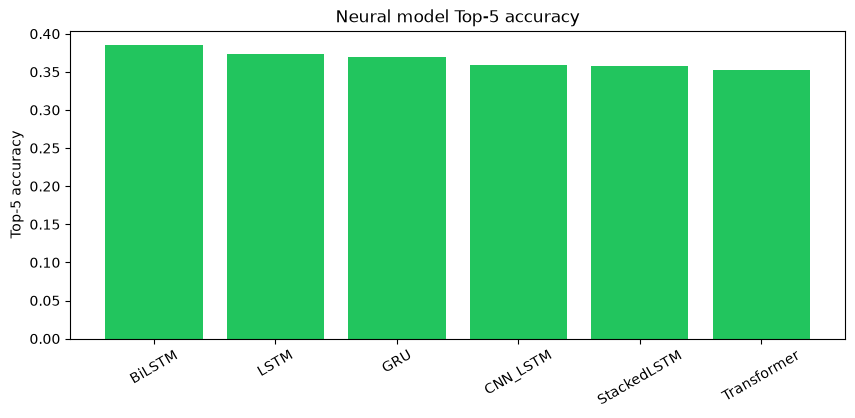

In [2]:

import matplotlib.pyplot as plt

neural = leaderboard[leaderboard["family"] == "neural"].copy()
neural = neural.sort_values("top5_accuracy", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(neural["model"], neural["top5_accuracy"], color="#22c55e")
plt.title("Neural model Top-5 accuracy")
plt.ylabel("Top-5 accuracy")
plt.xticks(rotation=30)
plt.show()



## Interpretation
Evaluate trade-off triangle:
- Accuracy/Perplexity
- Training time
- Inference latency and memory

Production model choice depends on quality target and latency budget.
